# **Encoder-Decoder models for Neural Machine Translation**



## **1. Overview and Theoretical Framework**

### **1.1 Introduction to Neural Machine Translation**

**Neural Machine Translation (NMT)** represents a paradigm shift from traditional statistical approaches to deep learning-based translation systems. This tutorial demonstrates the implementation of a **sequence-to-sequence (Seq2Seq) model** for translating German text to English.

### **1.2 The Final Goal**

In this notebook, our objective is to build a **Hindi-to-English machine translation system** using an **encoder-decoder architecture**. This framework is widely used for sequence-to-sequence tasks, where an input sentence in one language is transformed into a corresponding sentence in another.

The encoder-decoder model offers several important advantages for translation:

1. **Sequence Understanding**: The encoder reads the Hindi input sentence and converts it into a meaningful context representation.
2. **Context Preservation**: The model captures semantic and grammatical relationships across the full sentence.
3. **Flexible Output Generation**: The decoder generates the English translation word by word, allowing variable-length outputs.
4. **End-to-End Learning**: The entire model learns directly from parallel Hindi-English sentence pairs without manual rule design.

The following diagram illustrates the basic workflow of an encoder-decoder translation model:

```text
Hindi Input Sentence -> [Embedding Layer] -> [Encoder RNN/LSTM] -> [Context Vector]
                                                               |
                                                               v
English Output Sentence <- [Decoder RNN/LSTM] <- [Embedding Layer]

### **1.3 Architecture Components**

In this notebook, we build an NMT system consisting of the following key components:

| **Component** | **Function** | **Implementation** |
|---------------|--------------|-------------------|
| **Encoder** | Processes source language sequence into context vectors | LSTM with embeddings for the input hindi sentence|
| **Decoder** | Generates target language sequence using encoder outputs | an LSTM performing the english language generation |
| **Vocabulary Builder** | Maps tokens to numerical indices for neural processing | Custom Vocab class with special tokens |

## **2. Environment Setup**

In [50]:
import random
import math
import time
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from matplotlib import pyplot as plt


In [30]:


# ============================================================
# 1. CONFIG
# ============================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMBED_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 1
DROPOUT = 0.4
BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 5
MAX_LEN = 20
MIN_FREQ = 2
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

## **3. Dataset**

In [31]:

#
# Dataset:
# https://huggingface.co/datasets/cfilt/iitb-english-hindi
#
# Approx size:
# ~1.5 million sentence pairs
#
# For faster experimentation, we load only a subset initially.
# Once the pipeline works well, you can remove the subset limits
# and train on the full dataset.

from datasets import load_dataset

# ------------------------------------------------------------
# Step 1: Download and load dataset
# ------------------------------------------------------------
# This downloads the dataset (if not already cached locally)
# and loads train / validation splits.
dataset = load_dataset("cfilt/iitb-english-hindi")

# Print available dataset splits
print("Available splits:", dataset)

# ------------------------------------------------------------
# Step 2: Select smaller subset for faster prototyping
# ------------------------------------------------------------
# Training subset:
# Use first 100k examples (or less if dataset is smaller)
train_raw = dataset["train"].select(
    range(min(100000, len(dataset["train"])))
)

# Validation subset:
# Use first 5k examples
valid_raw = dataset["validation"].select(
    range(min(5000, len(dataset["validation"])))
)

# Print subset sizes
print(f"Training samples selected: {len(train_raw)}")
print(f"Validation samples selected: {len(valid_raw)}")


# ------------------------------------------------------------
# Step 3: Extract Hindi-English sentence pairs
# ------------------------------------------------------------
# Each sample has structure:
# {
#   "translation": {
#       "hi": "...",
#       "en": "..."
#   }
# }
#
# We convert this into:
# [
#   ("Hindi sentence", "English sentence"),
#   ...
# ]
def extract_pairs(hf_split):
    pairs = []

    for sample in hf_split:
        # Remove leading/trailing whitespace
        hi = sample["translation"]["hi"].strip()
        en = sample["translation"]["en"].strip()

        # Ignore empty pairs
        if hi and en:
            pairs.append((hi, en))

    return pairs


# Extract clean sentence pairs
parallel_data = extract_pairs(train_raw)
valid_parallel_data = extract_pairs(valid_raw)


# ------------------------------------------------------------
# Step 4: Inspect extracted data
# ------------------------------------------------------------
print(f"\nFinal usable training pairs: {len(parallel_data)}")
print(f"Final usable validation pairs: {len(valid_parallel_data)}")

# Print a few example pairs for sanity check
print("\nSample Hindi-English pairs:")
for i in range(3):
    print(f"\nExample {i+1}")
    print("Hindi   :", parallel_data[i][0])
    print("English :", parallel_data[i][1])

Available splits: DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 1659083
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 520
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 2507
    })
})
Training samples selected: 100000
Validation samples selected: 520

Final usable training pairs: 100000
Final usable validation pairs: 520

Sample Hindi-English pairs:

Example 1
Hindi   : अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें
English : Give your application an accessibility workout

Example 2
Hindi   : एक्सेर्साइसर पहुंचनीयता अन्वेषक
English : Accerciser Accessibility Explorer

Example 3
Hindi   : निचले पटल के लिए डिफोल्ट प्लग-इन खाका
English : The default plugin layout for the bottom panel


## **4. Tokenization and Vocabulary**

In [33]:
# ============================================================
# TOKENIZATION
# ============================================================
# This function converts a sentence into a list of words.
# For now, we use simple whitespace tokenization:
# Example:
# "मैं स्कूल जाता हूँ" -> ["मैं", "स्कूल", "जाता", "हूँ"]
#
# Note:
# This is a basic approach and works for initial experiments.


def tokenize(text):
    return text.strip().split()

In [34]:

# ============================================================
# VOCAB BUILDING
# ============================================================
# We build a vocabulary (word-to-index mapping) separately for:
# 1. Source language (Hindi)
# 2. Target language (English)
#
# Special tokens:
# <pad> : padding token for equal-length batches
# <sos> : start-of-sequence token
# <eos> : end-of-sequence token
# <unk> : unknown token for unseen words
#
# min_freq:
# Only keep words appearing at least min_freq times.
# This helps reduce vocabulary size and noise.

from collections import Counter

def build_vocab(sentences, min_freq=1):
    counter = Counter()

    # Count word frequencies across all sentences
    for sentence in sentences:
        counter.update(tokenize(sentence))

    # Initialize vocab with special tokens
    vocab = {
        PAD_TOKEN: 0,
        SOS_TOKEN: 1,
        EOS_TOKEN: 2,
        UNK_TOKEN: 3,
    }

    # Add words meeting minimum frequency threshold
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab



In [35]:

# ------------------------------------------------------------
# Step 1: Separate Hindi and English sentences
# ------------------------------------------------------------
hindi_sentences = [pair[0] for pair in parallel_data]
english_sentences = [pair[1] for pair in parallel_data]

print(f"Total Hindi training sentences   : {len(hindi_sentences)}")
print(f"Total English training sentences : {len(english_sentences)}")


# ------------------------------------------------------------
# Step 2: Build vocabularies
# ------------------------------------------------------------
# Source vocabulary = Hindi
src_vocab = build_vocab(hindi_sentences, MIN_FREQ)

# Target vocabulary = English
trg_vocab = build_vocab(english_sentences, MIN_FREQ)


# ------------------------------------------------------------
# Step 3: Store useful token indices
# ------------------------------------------------------------
# Padding token index used during batching
src_pad_idx = src_vocab[PAD_TOKEN]
trg_pad_idx = trg_vocab[PAD_TOKEN]

# Reverse target vocab:
# Used later to convert predicted token IDs back into words
idx_to_trg = {
    idx: word for word, idx in trg_vocab.items()
}


Total Hindi training sentences   : 100000
Total English training sentences : 100000


In [36]:

# ------------------------------------------------------------
# Step 4: Inspect vocabulary statistics
# ------------------------------------------------------------
print("\nVocabulary Statistics:")
print(f"Hindi vocabulary size   : {len(src_vocab)}")
print(f"English vocabulary size : {len(trg_vocab)}")

print("\nSpecial Token IDs:")
print(f"PAD = {src_vocab[PAD_TOKEN]}")
print(f"SOS = {src_vocab[SOS_TOKEN]}")
print(f"EOS = {src_vocab[EOS_TOKEN]}")
print(f"UNK = {src_vocab[UNK_TOKEN]}")


# ------------------------------------------------------------
# Step 5: Inspect sample vocabulary entries
# ------------------------------------------------------------
print("\nSample Hindi vocab words:")
for i, (word, idx) in enumerate(src_vocab.items()):
    print(f"{word} --> {idx}")
    if i == 9:
        break

print("\nSample English vocab words:")
for i, (word, idx) in enumerate(trg_vocab.items()):
    print(f"{word} --> {idx}")
    if i == 9:
        break


Vocabulary Statistics:
Hindi vocabulary size   : 9994
English vocabulary size : 10740

Special Token IDs:
PAD = 0
SOS = 1
EOS = 2
UNK = 3

Sample Hindi vocab words:
<pad> --> 0
<sos> --> 1
<eos> --> 2
<unk> --> 3
अपने --> 4
अनुप्रयोग --> 5
को --> 6
पहुंचनीयता --> 7
व्यायाम --> 8
का --> 9

Sample English vocab words:
<pad> --> 0
<sos> --> 1
<eos> --> 2
<unk> --> 3
Give --> 4
your --> 5
application --> 6
an --> 7
accessibility --> 8
workout --> 9


In [37]:
# ============================================================
#  ENCODING + PADDING
# ============================================================
# Neural networks cannot directly process raw text.
# So, we convert each sentence into a fixed-length sequence of token IDs.
#
# Main steps:
# 1. Tokenize sentence into words
# 2. Convert each word to its vocabulary index
# 3. Add <sos> and <eos> tokens
# 4. Pad shorter sentences with <pad>
# 5. Truncate longer sentences if needed


# ------------------------------------------------------------
# Step 1: Convert sentence into token IDs
# ------------------------------------------------------------
def encode(sentence, vocab, max_len):
    """
    Convert a sentence into a fixed-length sequence of token IDs.

    Args:
        sentence (str): input sentence
        vocab (dict): word-to-index mapping
        max_len (int): fixed sequence length

    Returns:
        list[int]: padded/truncated token ID sequence
    """

    # Split sentence into words
    tokens = tokenize(sentence)

    # Convert words to IDs
    # Unknown words are mapped to <unk>
    ids = [
        vocab.get(token, vocab[UNK_TOKEN])
        for token in tokens
    ]

    # Add start and end tokens
    ids = [vocab[SOS_TOKEN]] + ids + [vocab[EOS_TOKEN]]

    # Pad shorter sequences
    if len(ids) < max_len:
        ids += [vocab[PAD_TOKEN]] * (max_len - len(ids))

    # Truncate longer sequences
    else:
        ids = ids[:max_len]

    return ids



In [ ]:

# ------------------------------------------------------------
# Step 2: Create PyTorch Dataset
# ------------------------------------------------------------
# This dataset:
# - stores Hindi-English sentence pairs
# - converts them to token IDs on the fly
# - returns tensors for model training

from torch.utils.data import Dataset, DataLoader

class TranslationDataset(Dataset):
    def __init__(self, data, src_vocab, trg_vocab, max_len):
        """
        Args:
            data: list of (Hindi, English) sentence pairs
            src_vocab: Hindi vocabulary
            trg_vocab: English vocabulary
            max_len: fixed sequence length
        """
        self.data = data
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.max_len = max_len

    def __len__(self):
        # Total number of sentence pairs
        return len(self.data)

    def __getitem__(self, idx):
        # Get one Hindi-English sentence pair
        src, trg = self.data[idx]

        # Encode source (Hindi)
        src_ids = encode(
            src,
            self.src_vocab,
            self.max_len
        )

        # Encode target (English)
        trg_ids = encode(
            trg,
            self.trg_vocab,
            self.max_len
        )

        return {
            "src": torch.tensor(src_ids, dtype=torch.long),
            "trg": torch.tensor(trg_ids, dtype=torch.long),
        }



In [38]:

# ------------------------------------------------------------
# Step 3: Build training and validation datasets
# ------------------------------------------------------------
# We use:
# - parallel_data for training
# - valid_parallel_data for validation

train_dataset = TranslationDataset(
    parallel_data,
    src_vocab,
    trg_vocab,
    MAX_LEN
)

valid_dataset = TranslationDataset(
    valid_parallel_data,
    src_vocab,
    trg_vocab,
    MAX_LEN
)

print(f"Training dataset size   : {len(train_dataset)}")
print(f"Validation dataset size : {len(valid_dataset)}")


# ------------------------------------------------------------
# Step 4: Create DataLoaders
# ------------------------------------------------------------
# DataLoader helps:
# - batching
# - shuffling
# - parallel loading
#
# pin_memory:
# speeds transfer to GPU
#
# drop_last:
# drops incomplete last batch during training for stable shapes

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)



Training dataset size   : 100000
Validation dataset size : 520


In [39]:

# ------------------------------------------------------------
# Step 5: Inspect one batch
# ------------------------------------------------------------
sample_batch = next(iter(train_loader))

print("\nBatch inspection:")
print("Source batch shape :", sample_batch["src"].shape)
print("Target batch shape :", sample_batch["trg"].shape)

# Example:
# (batch_size, max_len)

print("\nSample encoded Hindi sentence:")
print(sample_batch["src"][0][:20])

print("\nSample encoded English sentence:")
print(sample_batch["trg"][0][:20])


Batch inspection:
Source batch shape : torch.Size([64, 20])
Target batch shape : torch.Size([64, 20])

Sample encoded Hindi sentence:
tensor([   1, 7378, 5133,    2,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])

Sample encoded English sentence:
tensor([   1, 1933, 6584,    2,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])


## **5. Model definition**

In [56]:
# ============================================================
# ENCODER
# ============================================================
# The encoder reads the Hindi input sentence and converts it into
# a compressed context representation.
#
# Workflow:
# Hindi sentence -> Embedding -> LSTM -> Final hidden + cell states
#
# These hidden states summarize the meaning of the source sentence
# and are passed to the decoder.



class Encoder(nn.Module):
    def __init__(
        self,
        input_dim,
        embed_dim,
        hidden_dim,
        num_layers,
        dropout
    ):
        """
        Encoder for source (Hindi) sentence.

        Args:
            input_dim: source vocabulary size
            embed_dim: embedding dimension
            hidden_dim: LSTM hidden size
            num_layers: number of LSTM layers
            dropout: dropout probability
        """
        super().__init__()

        # Convert token IDs into dense word embeddings
        self.embedding = nn.Embedding(
            input_dim,
            embed_dim,
            padding_idx=src_pad_idx
        )

        # Multi-layer LSTM encoder
        self.rnn = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        """
        Forward pass through encoder.

        Args:
            src: source token IDs
                 shape = (batch_size, src_len)

        Returns:
            hidden: final hidden state
            cell: final cell state
        """

        # Convert tokens to embeddings
        embedded = self.dropout(
            self.embedding(src)
        )

        # embedded shape:
        # (batch_size, src_len, embed_dim)

        # Pass sequence through LSTM
        _, (hidden, cell) = self.rnn(embedded)

        return hidden, cell



In [57]:

# ============================================================
# DECODER
# ============================================================
# The decoder generates English translation one word at a time.
#
# Workflow:
# Previous predicted word + encoder context -> LSTM -> next word prediction

class Decoder(nn.Module):
    def __init__(
        self,
        output_dim,
        embed_dim,
        hidden_dim,
        num_layers,
        dropout
    ):
        """
        Decoder for target (English) sentence.

        Args:
            output_dim: target vocabulary size
            embed_dim: embedding dimension
            hidden_dim: hidden state size
            num_layers: number of LSTM layers
            dropout: dropout probability
        """
        super().__init__()

        self.output_dim = output_dim

        # Embedding layer for target tokens
        self.embedding = nn.Embedding(
            output_dim,
            embed_dim,
            padding_idx=trg_pad_idx
        )

        # LSTM decoder
        self.rnn = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )

        # Final linear layer:
        # hidden state -> vocabulary logits
        self.fc = nn.Linear(
            hidden_dim,
            output_dim
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden, cell):
        """
        Decode one time step.

        Args:
            x: current input token
               shape = (batch_size,)
            hidden: previous hidden state
            cell: previous cell state

        Returns:
            prediction: next-word logits
            hidden: updated hidden state
            cell: updated cell state
        """

        # Add time dimension:
        # (batch_size,) -> (batch_size, 1)
        x = x.unsqueeze(1)

        # Convert token to embedding
        embedded = self.dropout(
            self.embedding(x)
        )

        # embedded shape:
        # (batch_size, 1, embed_dim)

        # One decoder step
        output, (hidden, cell) = self.rnn(
            embedded,
            (hidden, cell)
        )

        # output shape:
        # (batch_size, 1, hidden_dim)

        # Convert hidden state to vocabulary scores
        prediction = self.fc(
            output.squeeze(1)
        )

        return prediction, hidden, cell



In [58]:

# ============================================================
# SEQ2SEQ MODEL
# ============================================================
# This combines encoder + decoder into one full translation model.
#
# Training process:
# 1. Encode Hindi sentence
# 2. Use encoder final state as decoder initial state
# 3. Generate English tokens step-by-step
# 4. Use teacher forcing sometimes for stable training

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        """
        Full sequence-to-sequence translation model.
        """
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(
        self,
        src,
        trg,
        teacher_forcing_ratio=0.5
    ):
        """
        Forward pass for training.

        Args:
            src: Hindi sentence IDs
                 shape = (batch_size, src_len)
            trg: English sentence IDs
                 shape = (batch_size, trg_len)
            teacher_forcing_ratio:
                 probability of using ground truth token

        Returns:
            outputs:
                shape = (batch_size, trg_len, vocab_size)
        """

        batch_size = src.size(0)
        trg_len = trg.size(1)
        trg_vocab_size = self.decoder.output_dim

        # Store predictions for all time steps
        outputs = torch.zeros(
            batch_size,
            trg_len,
            trg_vocab_size
        ).to(self.device)

        # Encode source sentence
        hidden, cell = self.encoder(src)

        # First decoder input = <sos>
        x = trg[:, 0]

        # Decode step by step
        for t in range(1, trg_len):

            # Predict next token
            output, hidden, cell = self.decoder(
                x,
                hidden,
                cell
            )

            # Store prediction
            outputs[:, t, :] = output

            # Best predicted token
            best_guess = output.argmax(1)

            # Teacher forcing:
            # use true token sometimes
            teacher_force = (
                random.random() < teacher_forcing_ratio
            )

            x = trg[:, t] if teacher_force else best_guess

        return outputs


# ------------------------------------------------------------
# inspect model flow with one batch
# ------------------------------------------------------------
print("\nModel components defined successfully:")
print("Encoder: converts Hindi sentence into context vector")
print("Decoder: generates English translation word-by-word")
print("Seq2Seq: full translation pipeline")


Model components defined successfully:
Encoder: converts Hindi sentence into context vector
Decoder: generates English translation word-by-word
Seq2Seq: full translation pipeline


## **6. Training**

In [59]:
# ============================================================
# MODEL SETUP
# ============================================================
# Now we initialize the encoder-decoder translation model,
# define the optimizer, and set up the loss function.
#
# Components:
# - Encoder: processes Hindi sentence
# - Decoder: generates English translation
# - Seq2Seq: full model
# - Optimizer: updates model weights
# - Loss: compares predicted English tokens vs true tokens


# ------------------------------------------------------------
# Step 1: Initialize encoder and decoder
# ------------------------------------------------------------
encoder = Encoder(
    input_dim=len(src_vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

decoder = Decoder(
    output_dim=len(trg_vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.4 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [60]:

# ------------------------------------------------------------
# Step 2: Build Seq2Seq model and move to device
# ------------------------------------------------------------
# DEVICE = "cuda" if GPU available else "cpu"

model = Seq2Seq(
    encoder,
    decoder,
    DEVICE
).to(DEVICE)

print("Model initialized successfully.")
print(f"Training device: {DEVICE}")

Model initialized successfully.
Training device: cuda


In [61]:


# ------------------------------------------------------------
# Step 3: Define optimizer
# ------------------------------------------------------------
# Adam optimizer is commonly used for NLP tasks.
#
# weight_decay:
# adds L2 regularization to reduce overfitting.

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=1e-5
)


# ------------------------------------------------------------
# Step 4: Define loss function
# ------------------------------------------------------------
# CrossEntropyLoss:
# compares predicted token probabilities with true token IDs.
#
# ignore_index:
# padding tokens should not contribute to loss.

criterion = nn.CrossEntropyLoss(
    ignore_index=trg_pad_idx
)


# ------------------------------------------------------------
# Step 5: Optional model parameter count
# ------------------------------------------------------------
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

print(f"Trainable parameters: {count_parameters(model):,}")


Trainable parameters: 6,204,660


In [62]:
# ============================================================
#  TRAINING FUNCTION
# ============================================================
# This function trains the model for one full epoch.

def train_epoch(
    model,
    loader,
    optimizer,
    criterion,
    clip=1.0
):
    model.train()
    total_loss = 0

    # Progress bar for batches
    for batch in tqdm(
        loader,
        desc="Training",
        leave=False
    ):

        # Move batch to device
        src = batch["src"].to(DEVICE)
        trg = batch["trg"].to(DEVICE)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        output = model(
            src,
            trg,
            teacher_forcing_ratio=0.5
        )

        # output shape:
        # (batch_size, trg_len, vocab_size)

        output_dim = output.shape[-1]

        # Ignore first token (<sos>) in loss
        output = output[:, 1:, :].reshape(
            -1,
            output_dim
        )

        trg = trg[:, 1:].reshape(-1)

        # Compute loss
        loss = criterion(
            output,
            trg
        )

        # Backpropagation
        loss.backward()

        # Gradient clipping:
        # prevents exploding gradients in RNNs
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            clip
        )

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)



In [63]:

# ============================================================
#  VALIDATION FUNCTION
# ============================================================
# This evaluates the model on validation data without updating weights.

def evaluate(
    model,
    loader,
    criterion
):
    model.eval()
    total_loss = 0

    with torch.no_grad():

        for batch in tqdm(
            loader,
            desc="Validation",
            leave=False
        ):

            src = batch["src"].to(DEVICE)
            trg = batch["trg"].to(DEVICE)

            # No teacher forcing during validation
            output = model(
                src,
                trg,
                teacher_forcing_ratio=0.0
            )

            output_dim = output.shape[-1]

            output = output[:, 1:, :].reshape(
                -1,
                output_dim
            )

            trg = trg[:, 1:].reshape(-1)

            loss = criterion(
                output,
                trg
            )

            total_loss += loss.item()

    return total_loss / len(loader)


In [64]:
# ============================================================
# TRAINING LOOP
# ============================================================
# Train the model for multiple epochs and monitor:
# - training loss
# - validation loss
# - epoch duration
#
# At the end, we also plot:
# - training loss curve
# - validation loss curve



print("\nStarting training...\n")

# Store losses for plotting
train_losses = []
valid_losses = []

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    start_time = time.time()

    # --------------------------------------------------------
    # Train for one epoch
    # --------------------------------------------------------
    train_loss = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    # --------------------------------------------------------
    # Validate
    # --------------------------------------------------------
    valid_loss = evaluate(
        model,
        valid_loader,
        criterion
    )

    epoch_time = time.time() - start_time

    # Save losses
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    # Print metrics
    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Valid Loss: {valid_loss:.4f} | "
        f"Time: {epoch_time:.2f}s"
    )

print("\nTraining complete.")



Starting training...


Epoch 1/5


Epoch 1/5 | Train Loss: 5.4660 | Valid Loss: 6.3989 | Time: 125.73s

Epoch 2/5


Epoch 2/5 | Train Loss: 3.9581 | Valid Loss: 6.0741 | Time: 125.05s

Epoch 3/5


Epoch 3/5 | Train Loss: 2.8449 | Valid Loss: 5.7930 | Time: 125.10s

Epoch 4/5


Epoch 4/5 | Train Loss: 2.1119 | Valid Loss: 5.8271 | Time: 124.99s

Epoch 5/5


Epoch 5/5 | Train Loss: 1.6276 | Valid Loss: 5.9832 | Time: 124.97s

Training complete.


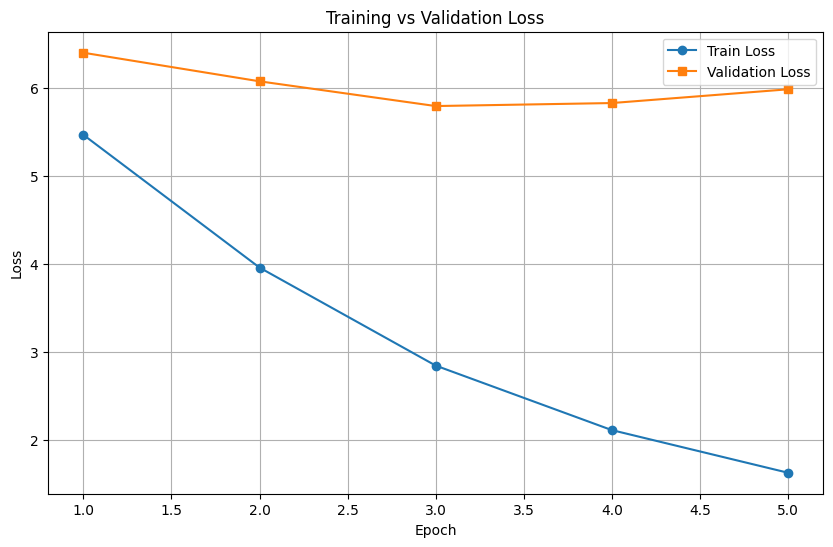

In [65]:


# ============================================================
# LOSS CURVE PLOTTING
# ============================================================
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker='o',
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    valid_losses,
    marker='s',
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## **7. Inference**

In [66]:
# ============================================================
#  INFERENCE / TESTING
# ============================================================
# This section uses the trained Seq2Seq model to translate
# new Hindi sentences into English.
#
# Inference pipeline:
# 1. Tokenize and encode Hindi sentence
# 2. Pass encoded sentence through encoder
# 3. Start decoder with <sos> token
# 4. Predict one English word at a time
# 5. Stop when <eos> token is generated


def translate_sentence(
    model,
    sentence,
    src_vocab,
    trg_vocab,
    idx_to_trg,
    max_len=30
):
    """
    Translate a Hindi sentence into English.

    Args:
        model: trained Seq2Seq model
        sentence (str): Hindi input sentence
        src_vocab (dict): Hindi vocabulary
        trg_vocab (dict): English vocabulary
        idx_to_trg (dict): reverse target vocab
        max_len (int): maximum decoding length

    Returns:
        translated English sentence (str)
    """

    # --------------------------------------------------------
    # Step 1: Switch model to evaluation mode
    # --------------------------------------------------------
    # Disables dropout for stable predictions
    model.eval()

    print("\n" + "=" * 60)
    print("NEW TRANSLATION REQUEST")
    print("=" * 60)

    print(f"\nInput Hindi sentence:\n{sentence}")

    # --------------------------------------------------------
    # Step 2: Encode source sentence
    # --------------------------------------------------------
    # Convert Hindi text -> token IDs
    src_ids = encode(
        sentence,
        src_vocab,
        max_len
    )

    print("\nEncoded Hindi token IDs:")
    print(src_ids)

    # Convert to tensor and add batch dimension
    # Shape:
    # (seq_len,) -> (1, seq_len)
    src_tensor = torch.tensor(
        src_ids,
        dtype=torch.long
    ).unsqueeze(0).to(DEVICE)

    print("\nSource tensor shape:")
    print(src_tensor.shape)

    # --------------------------------------------------------
    # Step 3: Pass sentence through encoder
    # --------------------------------------------------------
    with torch.no_grad():
        hidden, cell = model.encoder(src_tensor)

    print("\nEncoder output states:")
    print("Hidden shape:", hidden.shape)
    print("Cell shape  :", cell.shape)

    # --------------------------------------------------------
    # Step 4: Start decoding
    # --------------------------------------------------------
    # First decoder input is <sos>
    outputs = [trg_vocab[SOS_TOKEN]]

    print("\nStarting greedy decoding...\n")

    for step in range(max_len):

        # Previous predicted token
        prev_word = torch.tensor(
            [outputs[-1]],
            dtype=torch.long
        ).to(DEVICE)

        # Predict next token
        with torch.no_grad():
            output, hidden, cell = model.decoder(
                prev_word,
                hidden,
                cell
            )

        # Select token with highest probability
        pred_token = output.argmax(1).item()

        # Save predicted token
        outputs.append(pred_token)

        # Convert token ID to word (if exists)
        pred_word = idx_to_trg.get(pred_token, "<unk>")

        print(
            f"Step {step + 1:02d} | "
            f"Predicted token ID: {pred_token} | "
            f"Word: {pred_word}"
        )

        # Stop if end-of-sequence predicted
        if pred_token == trg_vocab[EOS_TOKEN]:
            print("\n<eos> token reached. Stopping decoding.")
            break

    # --------------------------------------------------------
    # Step 5: Convert predicted token IDs back to words
    # --------------------------------------------------------
    translated_tokens = [
        idx_to_trg[idx]
        for idx in outputs[1:]
        if idx not in {
            trg_vocab[EOS_TOKEN],
            trg_pad_idx
        }
    ]

    translated_sentence = " ".join(translated_tokens)

    print("\nFinal translated tokens:")
    print(translated_tokens)

    return translated_sentence

In [79]:

# ============================================================
# TEST ON SAMPLE SENTENCE
# ============================================================
# Test translation on a Hindi sentence

sample_sentence = "सीमांत रंगः"

translation = translate_sentence(
    model,
    sample_sentence,
    src_vocab,
    trg_vocab,
    idx_to_trg
)

print("\n" + "=" * 60)
print("FINAL TRANSLATION")
print("=" * 60)
print("Hindi Input :", sample_sentence)
print("English Out :", translation)


NEW TRANSLATION REQUEST

Input Hindi sentence:
सीमांत रंगः

Encoded Hindi token IDs:
[1, 42, 329, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Source tensor shape:
torch.Size([1, 30])

Encoder output states:
Hidden shape: torch.Size([1, 1, 256])
Cell shape  : torch.Size([1, 1, 256])

Starting greedy decoding...

Step 01 | Predicted token ID: 1849 | Word: Font
Step 02 | Predicted token ID: 326 | Word: color:
Step 03 | Predicted token ID: 2 | Word: <eos>

<eos> token reached. Stopping decoding.

Final translated tokens:
['Font', 'color:']

FINAL TRANSLATION
Hindi Input : सीमांत रंगः
English Out : Font color:
